In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
DATA_PATH = Path("../data/raw/bank.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (11162, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [6]:
target_col = "deposit"

target_counts = df[target_col].value_counts()
target_proportions = df[target_col].value_counts(normalize=True)

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_proportions,
})

target_summary

,count,proportion
deposit,,
no,5873,0.5262
yes,5289,0.4738


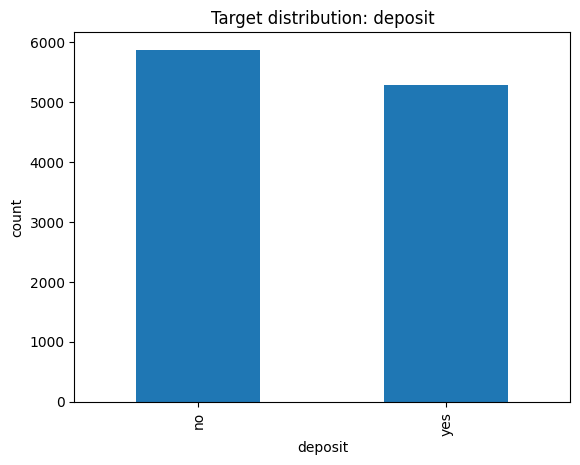

In [7]:
target_counts.plot(kind="bar")
plt.title("Target distribution: deposit")
plt.xlabel("deposit")
plt.ylabel("count")
plt.show()

Ячейка 8 — feature groups

In [8]:
target_col = "deposit"

numeric_cols_all = df.drop(columns=[target_col]).select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.drop(columns=[target_col]).select_dtypes(exclude=["number"]).columns.tolist()

leakage_risk_cols = ["duration"]

numeric_cols_model_candidate = [
    col for col in numeric_cols_all
    if col not in leakage_risk_cols
]

print("All numeric columns:")
print(numeric_cols_all)

print("\nNumeric model candidate columns:")
print(numeric_cols_model_candidate)

print("\nCategorical columns:")
print(categorical_cols)

print("\nLeakage-risk columns:")
print(leakage_risk_cols)

All numeric columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Numeric model candidate columns:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Leakage-risk columns:
['duration']


## Stage 2 EDA scope

This notebook performs initial exploratory data analysis for `04_bank_marketing`.

Important constraints:

- No model training in this notebook.
- No train/test split yet.
- No fitting of imputers, scalers, encoders, or other preprocessing objects.
- `duration` is analyzed only as a leakage-risk feature.
- `duration` is not considered a planned model feature for the pre-contact prediction task.
- `unknown` values are kept as categorical levels during EDA.

Ячейка — numerical summary

In [9]:
numeric_eda_cols = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
    "duration",
]

df[numeric_eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0000,41.2319,11.9134,18.0000,32.0000,39.0000,49.0000,95.0000
balance,11162.0000,1528.5385,3225.4133,-6847.0000,122.0000,550.0000,1708.0000,81204.0000
day,11162.0000,15.6580,8.4207,1.0000,8.0000,15.0000,22.0000,31.0000
campaign,11162.0000,2.5084,2.7221,1.0000,1.0000,2.0000,3.0000,63.0000
pdays,11162.0000,51.3304,108.7583,-1.0000,-1.0000,-1.0000,20.7500,854.0000
previous,11162.0000,0.8326,2.2920,0.0000,0.0000,0.0000,1.0000,58.0000
duration,11162.0000,371.9938,347.1284,2.0000,138.0000,255.0000,496.0000,3881.0000


Ячейка — skewness

In [10]:
df[numeric_eda_cols].skew().sort_values(ascending=False)

balance    8.2246
previous   7.3353
campaign   5.5456
pdays      2.4500
duration   2.1437
age        0.8628
day        0.1113
dtype: float64

Ячейка — percentiles

In [11]:
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

df[numeric_eda_cols].quantile(percentiles).T

,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900
age,22.0000,26.0000,32.0000,39.0000,49.0000,61.0000,77.0000
balance,-522.0000,-54.9500,122.0000,550.0000,1708.0000,6026.4500,13226.9800
day,1.0000,3.0000,8.0000,15.0000,22.0000,30.0000,31.0000
campaign,1.0000,1.0000,1.0000,2.0000,3.0000,7.0000,13.0000
pdays,-1.0000,-1.0000,-1.0000,-1.0000,20.7500,326.0000,425.3900
previous,0.0000,0.0000,0.0000,0.0000,1.0000,5.0000,10.0000
duration,14.0000,51.0000,138.0000,255.0000,496.0000,1079.9000,1577.1700


Ячейка — numeric summary by target

In [12]:
df.groupby(target_col)[numeric_eda_cols].agg(["mean", "median", "std"]).T

deposit                no       yes
age      mean     40.8374   41.6701
         median   39.0000   38.0000
         std      10.2648   13.4978
balance  mean   1280.2271 1804.2679
         median  414.0000  733.0000
         std    2933.4119 3501.1048
day      mean     16.1081   15.1583
         median   16.0000   15.0000
         std       8.3221    8.5019
campaign mean      2.8393    2.1410
         median    2.0000    2.0000
         std       3.2445    1.9218
pdays    mean     35.6853   68.7030
         median   -1.0000   -1.0000
         std      96.1829  118.8223
previous mean      0.5284    1.1704
         median    0.0000    0.0000
         std       1.9796    2.5533
duration mean    223.1303  537.2946
         median  163.0000  426.0000
         std     208.5775  392.5253

Ячейка — histograms

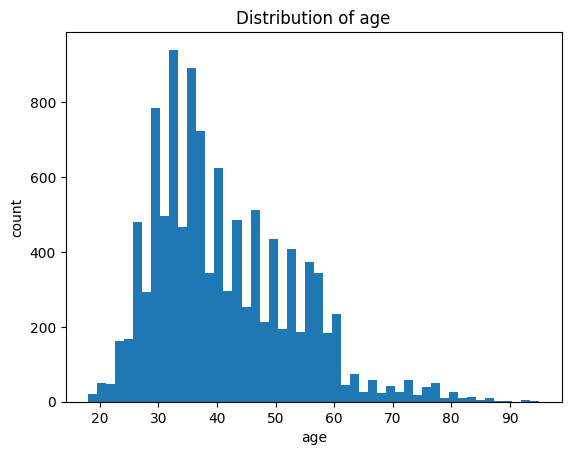

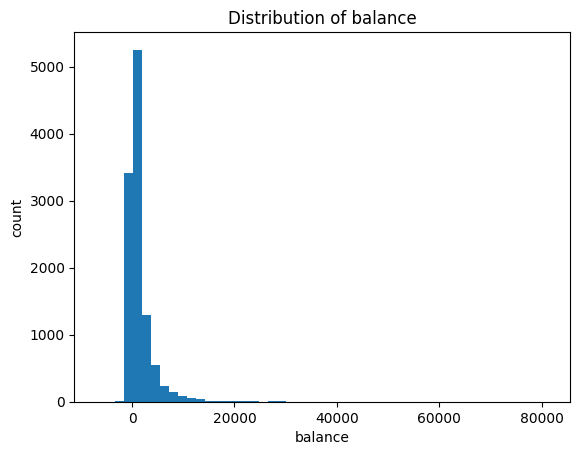

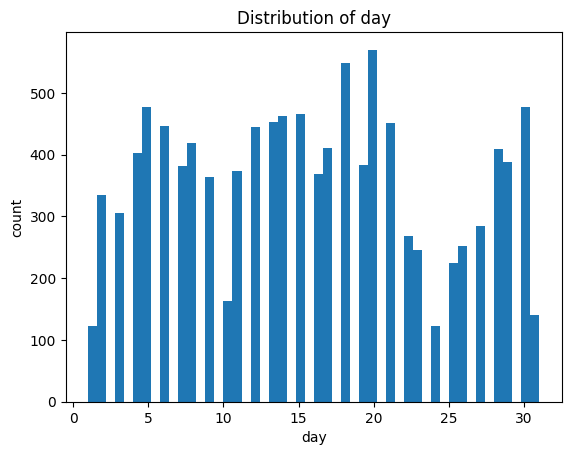

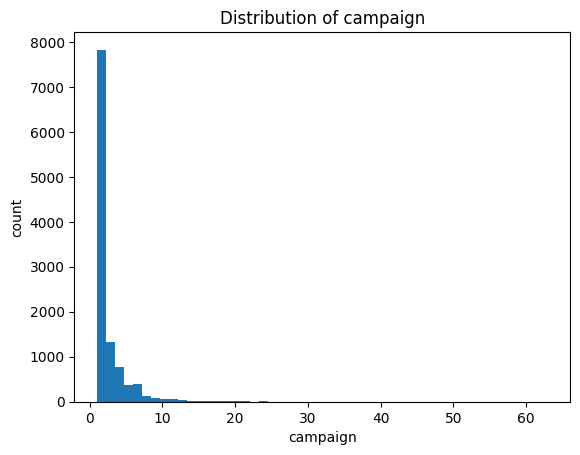

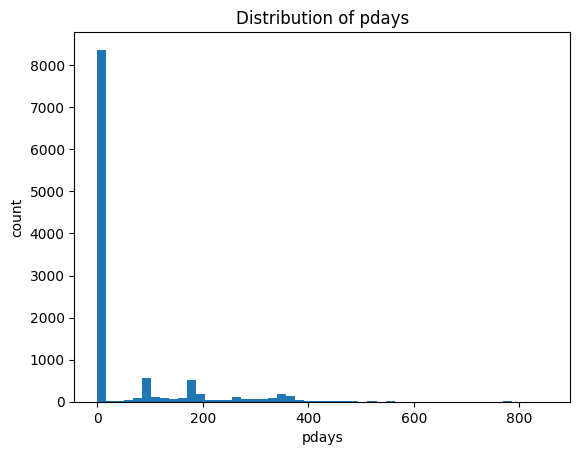

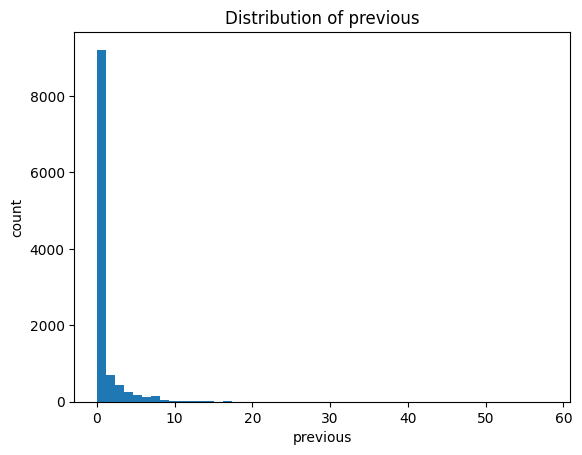

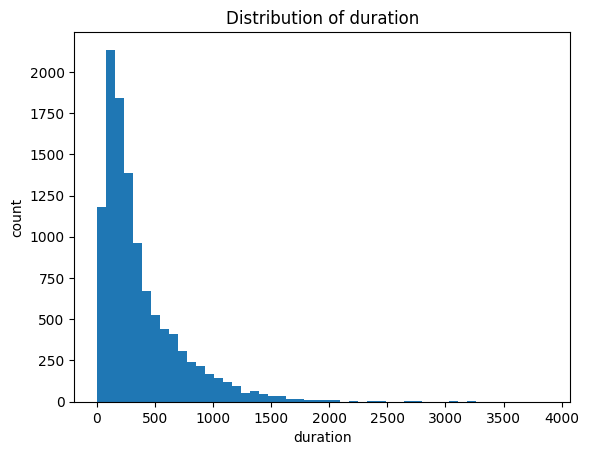

In [13]:
for col in numeric_eda_cols:
    df[col].plot(kind="hist", bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

Ячейка — boxplots by target

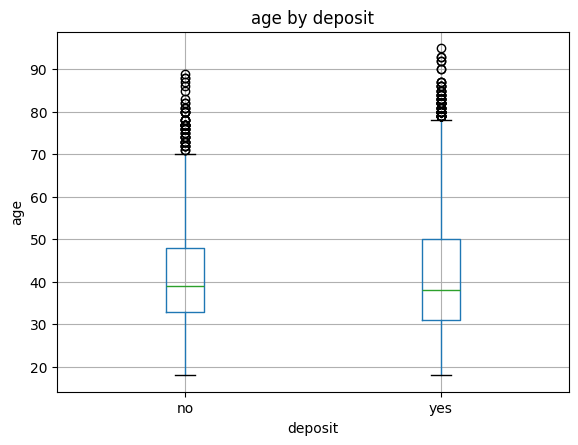

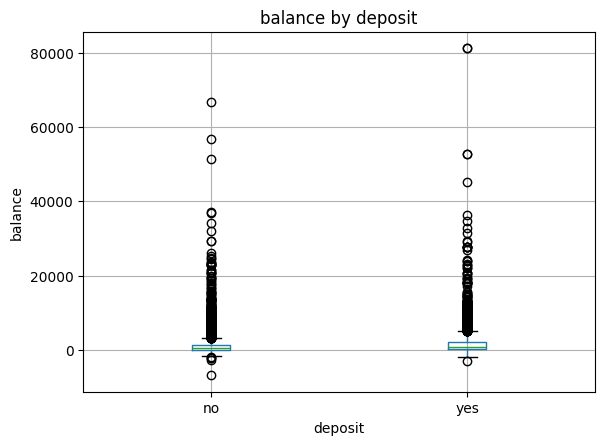

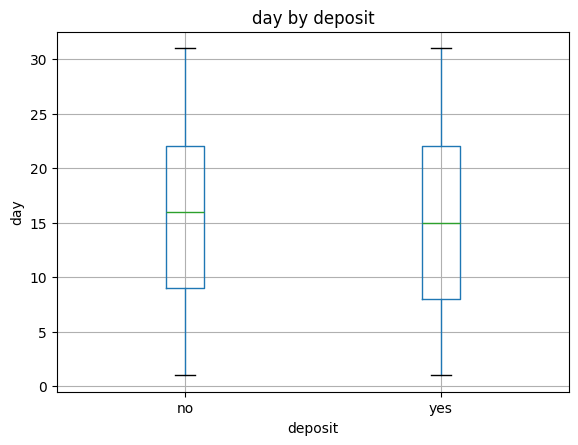

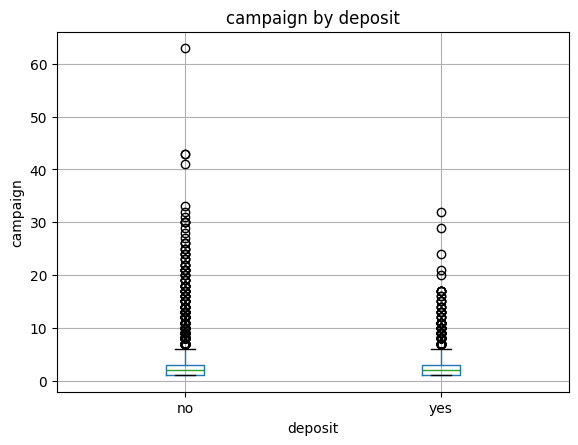

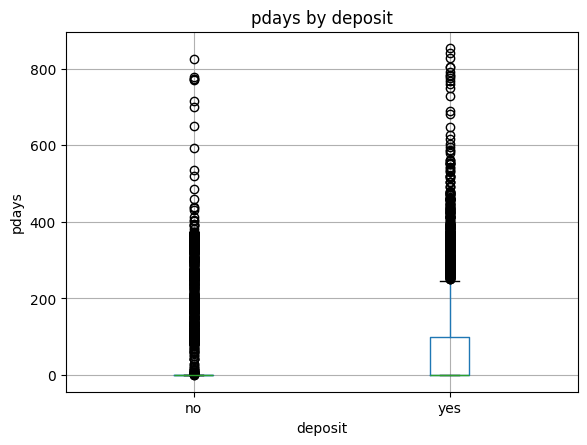

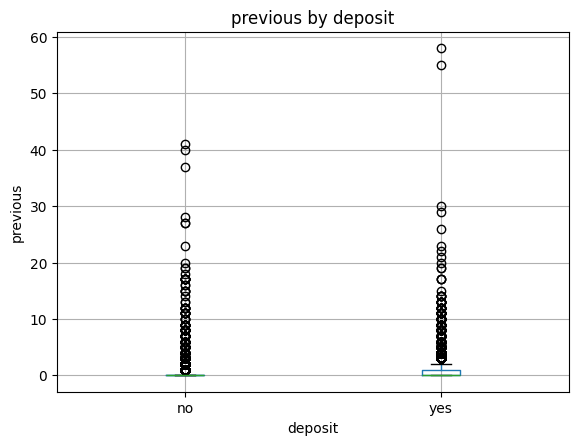

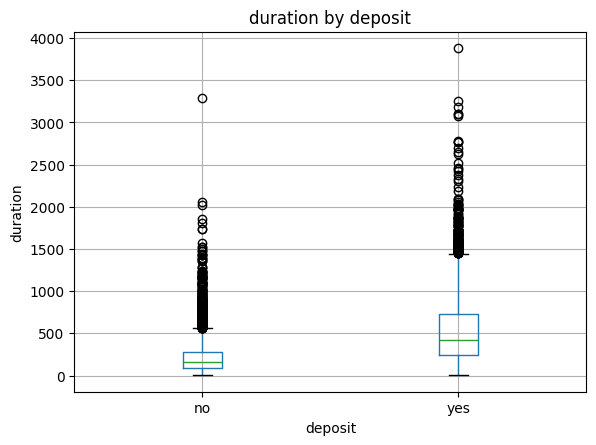

In [14]:
for col in numeric_eda_cols:
    df.boxplot(column=col, by=target_col)
    plt.title(f"{col} by {target_col}")
    plt.suptitle("")
    plt.xlabel(target_col)
    plt.ylabel(col)
    plt.show()

## Numerical features — initial observations

Numerical features analyzed:

- `age`
- `balance`
- `day`
- `campaign`
- `pdays`
- `previous`
- `duration`

Important note:

- `duration` is analyzed only to document leakage risk.
- It must be excluded from planned model features for pre-contact prediction.

Preliminary checks include:

- descriptive statistics;
- skewness;
- percentiles;
- distribution plots;
- comparison by `deposit`.

Ячейка — categorical frequency tables

In [15]:
for col in categorical_cols:
    summary = pd.DataFrame({
        "count": df[col].value_counts(dropna=False),
        "proportion": df[col].value_counts(normalize=True, dropna=False),
    })
    
    print(f"\n=== {col} ===")
    display(summary)


=== job ===


,count,proportion
job,,
management,2566,0.2299
blue-collar,1944,0.1742
technician,1823,0.1633
admin.,1334,0.1195
services,923,0.0827
retired,778,0.0697
self-employed,405,0.0363
student,360,0.0323
unemployed,357,0.0320



=== marital ===


,count,proportion
marital,,
married,6351,0.5690
single,3518,0.3152
divorced,1293,0.1158



=== education ===


...

,count,proportion
contact,,
cellular,8042,0.7205
unknown,2346,0.2102
telephone,774,0.0693



=== month ===


,count,proportion
month,,
may,2824,0.2530
aug,1519,0.1361
jul,1514,0.1356
jun,1222,0.1095
nov,943,0.0845
apr,923,0.0827
feb,776,0.0695
oct,392,0.0351
jan,344,0.0308



=== poutcome ===


,count,proportion
poutcome,,
unknown,8326,0.7459
failure,1228,0.1100
success,1071,0.0960
other,537,0.0481


Ячейка — helper function for deposit rate

In [16]:
def categorical_deposit_summary(data, col, target_col="deposit"):
    summary = (
        data
        .groupby(col)[target_col]
        .agg(
            count="count",
            deposit_yes_rate=lambda x: (x == "yes").mean(),
            deposit_yes_count=lambda x: (x == "yes").sum(),
            deposit_no_count=lambda x: (x == "no").sum(),
        )
        .sort_values("deposit_yes_rate", ascending=False)
    )
    return summary

Ячейка — deposit rate by important categorical features

In [17]:
important_categorical_cols = [
    "poutcome",
    "contact",
    "month",
    "housing",
    "loan",
    "job",
    "education",
]

for col in important_categorical_cols:
    print(f"\n=== Deposit rate by {col} ===")
    display(categorical_deposit_summary(df, col, target_col))


=== Deposit rate by poutcome ===


,count,deposit_yes_rate,deposit_yes_count,deposit_no_count
poutcome,,,,
success,1071,0.9132,978,93
other,537,0.5717,307,230
failure,1228,0.5033,618,610
unknown,8326,0.4067,3386,4940



=== Deposit rate by contact ===


,count,deposit_yes_rate,deposit_yes_count,deposit_no_count
contact,,,,
cellular,8042,0.5433,4369,3673
telephone,774,0.5039,390,384
unknown,2346,0.2259,530,1816



=== Deposit rate by month ===


...

,count,deposit_yes_rate,deposit_yes_count,deposit_no_count
loan,,,,
no,9702,0.4953,4805,4897
yes,1460,0.3315,484,976



=== Deposit rate by job ===


,count,deposit_yes_rate,deposit_yes_count,deposit_no_count
job,,,,
student,360,0.7472,269,91
retired,778,0.6632,516,262
unemployed,357,0.5658,202,155
management,2566,0.5070,1301,1265
unknown,70,0.4857,34,36
admin.,1334,0.4730,631,703
self-employed,405,0.4617,187,218
technician,1823,0.4608,840,983
services,923,0.3998,369,554



=== Deposit rate by education ===


,count,deposit_yes_rate,deposit_yes_count,deposit_no_count
education,,,,
tertiary,3689,0.5411,1996,1693
unknown,497,0.5070,252,245
secondary,5476,0.4474,2450,3026
primary,1500,0.3940,591,909


Ячейка — bar plots for deposit rate

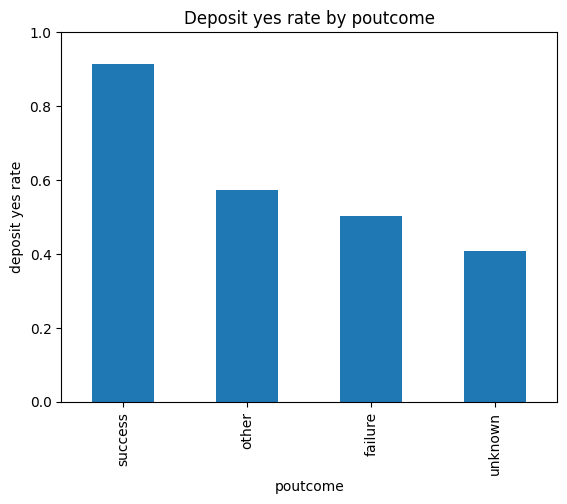

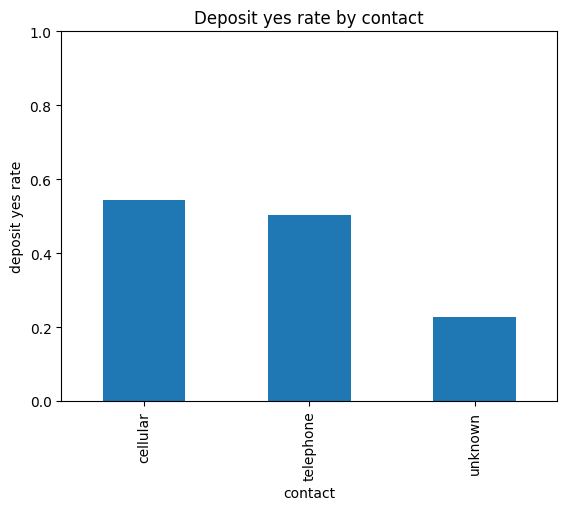

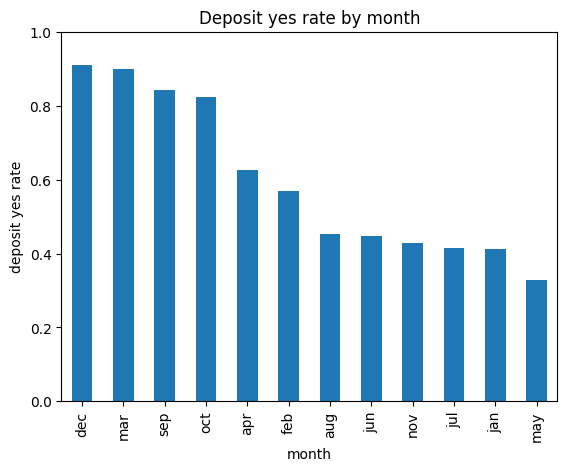

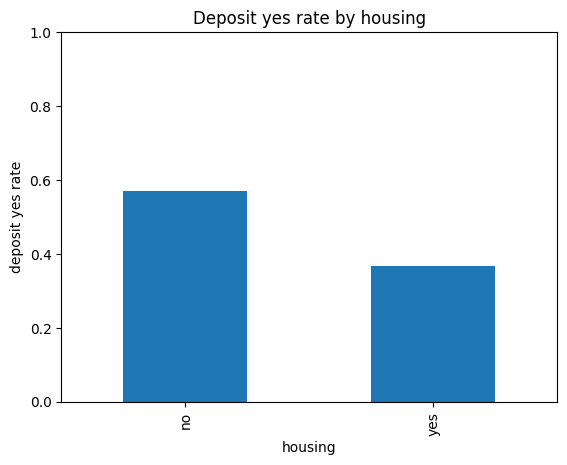

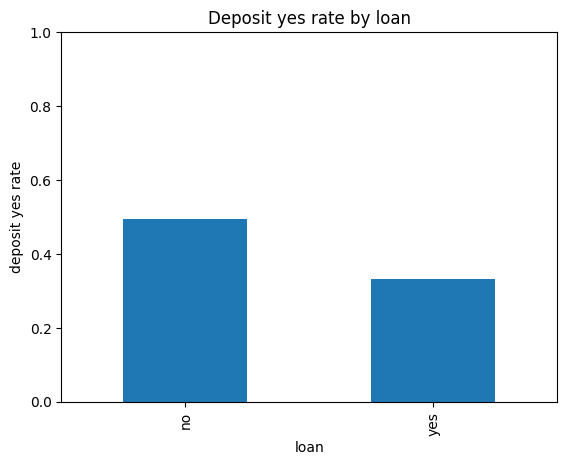

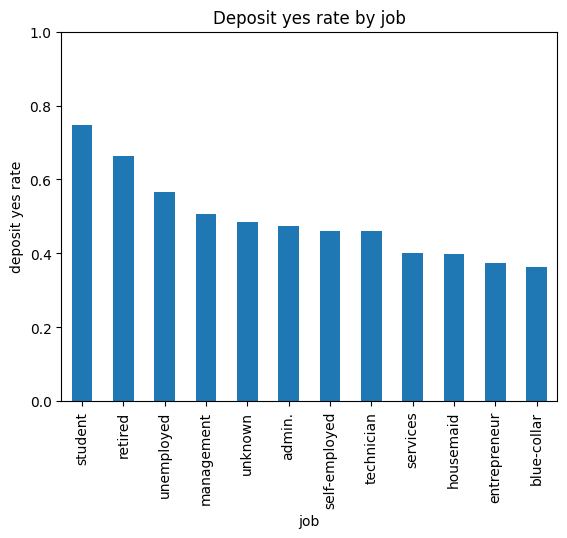

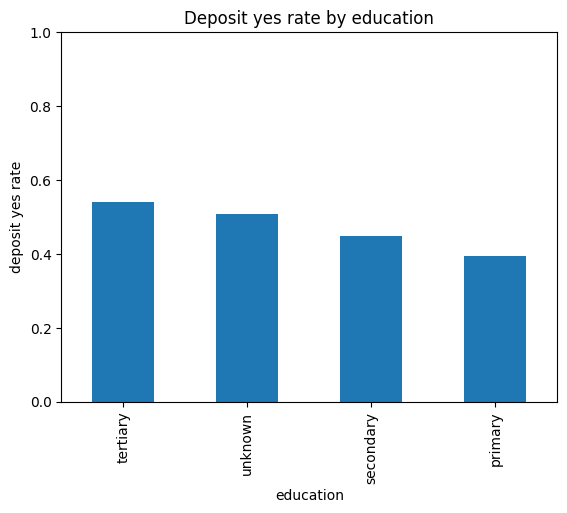

In [18]:
for col in important_categorical_cols:
    summary = categorical_deposit_summary(df, col, target_col)
    
    summary["deposit_yes_rate"].plot(kind="bar")
    plt.title(f"Deposit yes rate by {col}")
    plt.xlabel(col)
    plt.ylabel("deposit yes rate")
    plt.ylim(0, 1)
    plt.show()

## Categorical features — initial observations

Categorical features are low to moderate cardinality, so OneHotEncoder is a reasonable baseline preprocessing choice.

Important EDA focus:

- `poutcome`: previous campaign outcome, strong signal but not automatically leakage.
- `contact`: contains many `unknown` values and has different deposit rates.
- `month`: strong seasonal/campaign timing differences, but no year is available.
- `housing` and `loan`: likely related to customer financial situation.
- `job` and `education`: customer profile features.

No categorical preprocessing is fitted in this notebook.

Ячейка — unknown counts and percentages

In [19]:
unknown_summary = []

for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    unknown_pct = unknown_count / len(df)
    
    unknown_summary.append({
        "column": col,
        "unknown_count": unknown_count,
        "unknown_pct": unknown_pct,
    })

unknown_summary = (
    pd.DataFrame(unknown_summary)
    .sort_values("unknown_count", ascending=False)
)

unknown_summary

,column,unknown_count,unknown_pct
8,poutcome,8326,0.7459
6,contact,2346,0.2102
2,education,497,0.0445
0,job,70,0.0063
1,marital,0,0.0000
4,housing,0,0.0000
3,default,0,0.0000
5,loan,0,0.0000
7,month,0,0.0000


Ячейка — deposit relationship for unknown values

In [20]:
unknown_target_summary = []

for col in categorical_cols:
    mask_unknown = df[col] == "unknown"
    
    if mask_unknown.sum() == 0:
        continue
    
    unknown_target_summary.append({
        "column": col,
        "unknown_count": mask_unknown.sum(),
        "unknown_deposit_yes_rate": (df.loc[mask_unknown, target_col] == "yes").mean(),
        "known_count": (~mask_unknown).sum(),
        "known_deposit_yes_rate": (df.loc[~mask_unknown, target_col] == "yes").mean(),
    })

unknown_target_summary = (
    pd.DataFrame(unknown_target_summary)
    .sort_values("unknown_count", ascending=False)
)

unknown_target_summary

,column,unknown_count,unknown_deposit_yes_rate,known_count,known_deposit_yes_rate
3,poutcome,8326,0.4067,2836,0.6710
2,contact,2346,0.2259,8816,0.5398
1,education,497,0.5070,10665,0.4723
0,job,70,0.4857,11092,0.4738


Ячейка — detailed crosstab for unknown columns

In [21]:
unknown_cols = unknown_summary.loc[
    unknown_summary["unknown_count"] > 0,
    "column"
].tolist()

for col in unknown_cols:
    print(f"\n=== {col}: unknown relationship with deposit ===")
    temp = df.assign(is_unknown=df[col].eq("unknown"))
    display(pd.crosstab(temp["is_unknown"], temp[target_col], normalize="index"))
    display(pd.crosstab(temp["is_unknown"], temp[target_col]))


=== poutcome: unknown relationship with deposit ===


deposit,no,yes
is_unknown,,
False,0.3290,0.6710
True,0.5933,0.4067


deposit,no,yes
is_unknown,,
False,933,1903
True,4940,3386



=== contact: unknown relationship with deposit ===


deposit,no,yes
is_unknown,,
False,0.4602,0.5398
True,0.7741,0.2259


...

deposit,no,yes
is_unknown,,
False,0.5277,0.4723
True,0.4930,0.5070


deposit,no,yes
is_unknown,,
False,5628,5037
True,245,252



=== job: unknown relationship with deposit ===


deposit,no,yes
is_unknown,,
False,0.5262,0.4738
True,0.5143,0.4857


deposit,no,yes
is_unknown,,
False,5837,5255
True,36,34


## Unknown values analysis

Several categorical columns contain the literal category `unknown`.

Important decision:

- Do not automatically convert `unknown` to NaN at this stage.
- Treat `unknown` as an observed category during initial EDA.
- In the first preprocessing pipeline, `unknown` can be passed to OneHotEncoder as a regular category.

Reason:

`unknown` may be informative. For example, `poutcome=unknown` often means there was no previous campaign outcome, and `contact=unknown` has a noticeably different deposit rate.

Ячейка — numeric correlations

In [22]:
numeric_corr_cols = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
    "duration",
]

corr_matrix = df[numeric_corr_cols].corr()

corr_matrix

,age,balance,day,campaign,pdays,previous,duration
age,1.0000,0.1123,-0.0008,-0.0053,0.0028,0.0202,0.0002
balance,0.1123,1.0000,0.0105,-0.0139,0.0174,0.0308,0.0224
day,-0.0008,0.0105,1.0000,0.1370,-0.0772,-0.0590,-0.0185
campaign,-0.0053,-0.0139,0.1370,1.0000,-0.1027,-0.0497,-0.0416
pdays,0.0028,0.0174,-0.0772,-0.1027,1.0000,0.5073,-0.0274
previous,0.0202,0.0308,-0.0590,-0.0497,0.5073,1.0000,-0.0267
duration,0.0002,0.0224,-0.0185,-0.0416,-0.0274,-0.0267,1.0000


Ячейка — correlation heatmap

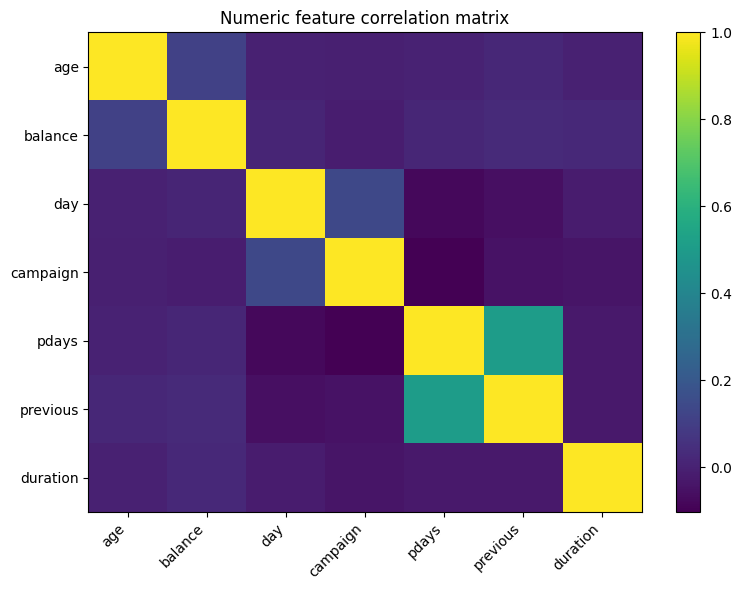

In [23]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Numeric feature correlation matrix")
plt.tight_layout()
plt.show()

Ячейка — correlation with encoded target, only for EDA

Это не preprocessing для модели, только EDA.

In [24]:
target_binary = df[target_col].map({"no": 0, "yes": 1})

numeric_target_corr = (
    df[numeric_corr_cols]
    .corrwith(target_binary)
    .sort_values(ascending=False)
)

numeric_target_corr

duration    0.4519
pdays       0.1516
previous    0.1399
balance     0.0811
age         0.0349
day        -0.0563
campaign   -0.1281
dtype: float64

## Numeric correlations

Numeric correlations were checked only for EDA.

Important caution:

- Correlation captures mostly linear relationships.
- Low correlation does not mean a feature is useless.
- High correlation with target does not prove causality.
- `duration` correlation with target is expected to be high but should not be used for the planned pre-contact model.

## Numeric correlations

Numeric correlations were checked only for EDA.

Important caution:

- Correlation captures mostly linear relationships.
- Low correlation does not mean a feature is useless.
- High correlation with target does not prove causality.
- `duration` correlation with target is expected to be high but should not be used for the planned pre-contact model.

In [ ]:
## Numeric skew and possible outliers

Several numeric features are strongly right-skewed:

- `balance`
- `previous`
- `campaign`
- `pdays`
- `duration`

Important observations:

- `balance` has negative values and a very large right tail.
- `campaign` has a long right tail, with some clients contacted many times during the campaign.
- `previous` is zero for many clients and has a long right tail.
- `pdays` contains a special value `-1`, likely meaning no previous contact.
- `duration` is right-skewed and highly related to the target, but it is treated as leakage-risk.

No outliers are removed at this stage.

Reason:

- EDA is not a data cleaning stage by default.
- Some extreme values may be real business observations.
- Any transformation/removal must be justified and later performed inside a reproducible pipeline or documented preprocessing step.

## Duration leakage documentation

`duration` is highly predictive of `deposit`.

Observed relationship:

- clients with `deposit=yes` have much higher average and median call duration;
- clients with `deposit=no` have much shorter calls on average.

Why this is predictive:

Longer calls often mean stronger client engagement, more detailed discussion, and higher chance of subscription.

Why this is leakage for pre-contact prediction:

The planned business task is to predict whether a client is likely to subscribe before the marketing contact outcome is known.

At that decision point, call duration is not available yet.

Using `duration` would allow the model to use information from during/after the contact, making offline metrics unrealistically high and not representative of real deployment.

Decision:

- `duration` is excluded from planned model features.
- It is analyzed only to document leakage risk.

In [ ]:
## Preprocessing hypotheses for later stages

No preprocessing objects are fitted in this notebook.

Planned preprocessing hypotheses:

### Numeric features

Candidate numeric features:

- `age`
- `balance`
- `day`
- `campaign`
- `pdays`
- `previous`

Potential preprocessing:

- `SimpleImputer` later if needed, inside a Pipeline.
- Optional scaler for scale-sensitive models such as Logistic Regression or KNN.
- Robust scaling may be useful because several numeric features are skewed and contain large values.
- No numeric transformation is fitted at this stage.

### Categorical features

Candidate categorical features:

- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`
- `contact`
- `month`
- `poutcome`

Potential preprocessing:

- `SimpleImputer` later if needed, inside a Pipeline.
- `OneHotEncoder(handle_unknown="ignore")` inside ColumnTransformer.
- `unknown` values are treated as valid categories unless later evidence suggests a better treatment.

### Leakage handling

- `duration` must be excluded from the planned pre-contact model.
- Any threshold tuning must be done only on train/CV, not on the final test set.